<a href="https://colab.research.google.com/github/Shatha-1/Data-Science/blob/main/Untitled10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [28]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

In [29]:
GNEWS_PATH = "Gnews_all_labeled.csv"
YOUTUBE_PATH = "youtube_all_labeled.csv"

gnews = pd.read_csv(GNEWS_PATH)
youtube = pd.read_csv(YOUTUBE_PATH)

print("GNews shape:", gnews.shape)
print("YouTube shape:", youtube.shape)

youtube.head(10)

GNews shape: (110, 2)
YouTube shape: (3781, 2)


,text_clean,label
0,Crazy.,0
1,They aren't going to let us have this vaccine....,-1
2,Well...the rich will get vaccinated abroad if ...,1
3,I think I may have to get my vaccines in Canad...,-1
4,"So, Americans over 50 may have to get vaccinat...",1
5,Sounds like Trump's FDA trolling the waters fo...,-1
6,They want us also to die. End of story.,-1
7,There will be no more flu or Covid shots as lo...,-1
8,FUUUUUUUUCK I hate this fucking timeline.,-1
9,The Drug Hunters by Kirsch & Ogas gives the hi...,-1


In [30]:
gnews["source"] = "gnews"
youtube["source"] = "youtube"

In [31]:
df = pd.concat([gnews, youtube], ignore_index=True)

print("Combined shape:", df.shape)

Combined shape: (3891, 3)


In [32]:
df = df.dropna(subset=["text_clean", "label"]).copy()

df["text_clean"] = df["text_clean"].astype(str)
df["label"] = df["label"].astype(int)

print("Final shape:", df.shape)

print("\nLabel distribution:")
print(df["label"].value_counts())

print("\nSource distribution:")
print(df["source"].value_counts())

Final shape: (3891, 3)

Label distribution:
label
-1    2260
 0     839
 1     792
Name: count, dtype: int64

Source distribution:
source
youtube    3781
gnews       110
Name: count, dtype: int64


In [33]:
X = df["text_clean"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

print("Training size:", X_train.shape[0])
print("Testing size:", X_test.shape[0])

Training size: 3112
Testing size: 779


In [34]:
rf_model = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=5000,
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95
    )),
    ("random_forest", RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight="balanced"
    ))
])

In [35]:
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [36]:
y_pred = rf_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Random Forest Accuracy:", round(accuracy, 4))
print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["negative", "neutral", "positive"]
))

Random Forest Accuracy: 0.7214

Classification Report:
              precision    recall  f1-score   support

    negative       0.72      0.92      0.81       447
     neutral       0.68      0.59      0.63       182
    positive       0.88      0.30      0.45       150

    accuracy                           0.72       779
   macro avg       0.76      0.60      0.63       779
weighted avg       0.74      0.72      0.70       779



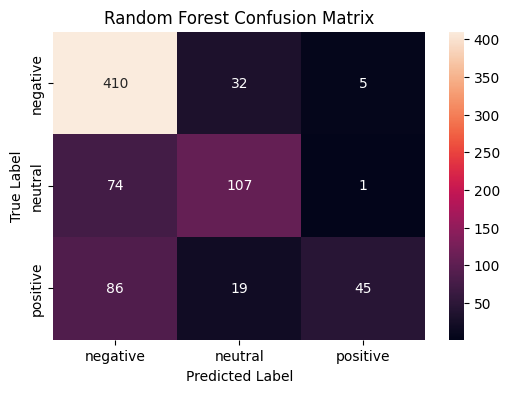

In [37]:
cm = confusion_matrix(y_test, y_pred, labels=[-1, 0, 1])

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["negative", "neutral", "positive"],
    yticklabels=["negative", "neutral", "positive"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Random Forest Confusion Matrix")
plt.show()

In [38]:
label_names = {
    -1: "negative",
    0: "neutral",
    1: "positive"
}

In [39]:
results = pd.DataFrame({
    "text_clean": X_test.values,
    "actual_label": y_test.values,
    "predicted_label": y_pred
})

results["actual_label_name"] = results["actual_label"].map(label_names)
results["predicted_label_name"] = results["predicted_label"].map(label_names)

results.to_csv("random_forest_test_predictions.csv", index=False)

print("Saved: random_forest_test_predictions.csv")
results.head()

Saved: random_forest_test_predictions.csv


,text_clean,actual_label,predicted_label,actual_label_name,predicted_label_name
0,My cholesterol and triglycerides arent very go...,1,-1,positive,negative
1,Are you not supposed to pull back,0,0,neutral,neutral
2,"Honesty is always the best policy, and we do n...",1,-1,positive,negative
3,Flu shots feel like nothing. So if you're here...,-1,-1,negative,negative
4,Thanks so much for your PSA and I hope people ...,1,1,positive,positive


In [40]:
summary = pd.DataFrame({
    "model": ["Random Forest"],
    "accuracy": [accuracy],
    "features": ["TF-IDF unigrams + bigrams"],
    "datasets_used": ["GNews labeled + YouTube labeled"]
})

summary.to_csv("random_forest_model_summary.csv", index=False)

summary

,model,accuracy,features,datasets_used
0,Random Forest,0.721438,TF-IDF unigrams + bigrams,GNews labeled + YouTube labeled
